# 03 — ML Applications: Decision Trees, Distillation & Perplexity

**Book reference:** *Practical Statistics for Data Scientists* (Bruce & Bruce) — Ch. 6 "Statistical Machine Learning," section "Measuring Homogeneity or Impurity" (entropy as a tree-splitting criterion, alongside Gini impurity).

Part of the Math Foundations chapter of the 6-month ML Engineer prep plan. This notebook is where entropy, cross-entropy, and KL divergence stop being abstract and turn into three concrete things you'll actually touch in practice.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

## Decision trees: entropy as a splitting criterion

A decision tree grows by repeatedly picking the split that reduces entropy the most. **Information gain** for a candidate split is:

```
Gain = H(parent) - Σ (|child| / |parent|) · H(child)
```

The tree greedily picks whichever available split maximizes this gain at each node — i.e., whichever split makes the resulting groups as *pure* (low-entropy) as possible.

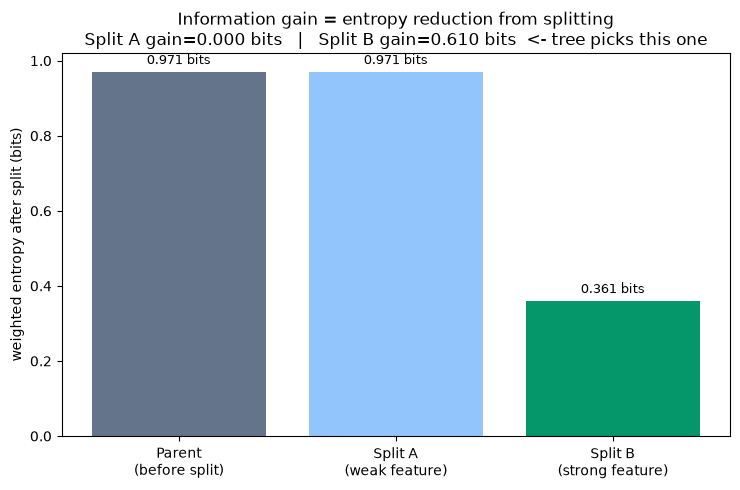

Split A information gain: 0.0000 bits (useless -- doesn't separate classes at all)
Split B information gain: 0.6100 bits (the tree greedily picks this)


In [2]:
def entropy(labels):
    labels = np.array(labels)
    _, counts = np.unique(labels, return_counts=True)
    p = counts / counts.sum()
    return -np.sum(p * np.log2(p))

def visualize_information_gain(savepath: Path = None):
    parent = [1]*6 + [0]*4       # 10 samples, mixed -> high entropy
    H_parent = entropy(parent)

    # Candidate split A: a weak/useless feature
    left_A, right_A = [1,1,1,0,0], [1,1,1,0,0]
    H_A = (len(left_A)/10)*entropy(left_A) + (len(right_A)/10)*entropy(right_A)
    gain_A = H_parent - H_A

    # Candidate split B: a strong feature
    left_B, right_B = [1,1,1,1,1], [0,0,0,0,1]
    H_B = (len(left_B)/10)*entropy(left_B) + (len(right_B)/10)*entropy(right_B)
    gain_B = H_parent - H_B

    fig, ax = plt.subplots(figsize=(7.5, 5))
    labels = ["Parent\n(before split)", "Split A\n(weak feature)", "Split B\n(strong feature)"]
    values = [H_parent, H_A, H_B]
    colors = ["#64748b", "#93c5fd", "#059669"]
    ax.bar(labels, values, color=colors)
    for i, v in enumerate(values):
        ax.text(i, v + 0.02, f"{v:.3f} bits", ha="center", fontsize=9)
    ax.set_ylabel("weighted entropy after split (bits)")
    ax.set_title(f"Information gain = entropy reduction from splitting\n"
                 f"Split A gain={gain_A:.3f} bits   |   Split B gain={gain_B:.3f} bits  <- tree picks this one")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()
    return gain_A, gain_B

gain_A, gain_B = visualize_information_gain(FIG_DIR / "information_gain.png")
print(f"Split A information gain: {gain_A:.4f} bits (useless -- doesn\'t separate classes at all)")
print(f"Split B information gain: {gain_B:.4f} bits (the tree greedily picks this)")

Split A leaves both children with the *exact same* class mixture as the parent — the feature told you nothing, and information gain correctly reports zero. Split B produces one pure child and one nearly-pure child — a large entropy reduction, and the split a real tree-growing algorithm (ID3, C4.5, and CART's entropy criterion — the alternative to Gini impurity from the Statistics chapter) would pick. This is the exact mechanism, not just an analogy: entropy from notebook 1 *is* the criterion.

## Knowledge distillation: temperature-scaled softmax and KL divergence

**Knowledge distillation** trains a smaller "student" model to mimic a larger "teacher" model's output distribution, rather than only the hard labels. The training objective is (a version of) KL divergence between the teacher's and student's predicted distributions — literally minimizing `KL(teacher ‖ student)`.

The trick that makes this work well: **temperature scaling**. Instead of the normal softmax, divide the logits by a temperature `T > 1` before applying softmax, which softens the distribution and reveals the teacher's *full ranking* of alternatives (its "dark knowledge"), not just its single top prediction.

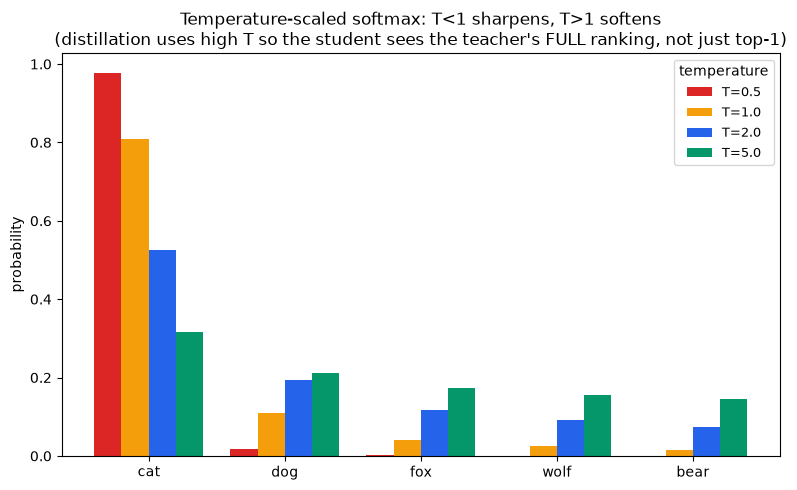

In [3]:
def softmax_temp(logits, T):
    z = logits / T
    z = z - z.max()
    e = np.exp(z)
    return e / e.sum()

def visualize_temperature_scaling(savepath: Path = None):
    logits = np.array([4.0, 2.0, 1.0, 0.5, 0.1])
    classes = ["cat", "dog", "fox", "wolf", "bear"]
    temps = [0.5, 1.0, 2.0, 5.0]

    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(classes))
    width = 0.2
    colors = ["#dc2626", "#f59e0b", "#2563eb", "#059669"]
    for i, T in enumerate(temps):
        probs = softmax_temp(logits, T)
        ax.bar(x + (i - 1.5) * width, probs, width, label=f"T={T}", color=colors[i])

    ax.set_xticks(x); ax.set_xticklabels(classes)
    ax.set_ylabel("probability")
    ax.legend(title="temperature", fontsize=9)
    ax.set_title("Temperature-scaled softmax: T<1 sharpens, T>1 softens\n(distillation uses high T so the student sees the teacher\'s FULL ranking, not just top-1)")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()

visualize_temperature_scaling(FIG_DIR / "temperature_scaling.png")

At `T=0.5` the model looks almost certain it's a cat and nothing else — useful for final predictions, but it hides the fact the teacher also thought "dog" was plausible and "bear" was essentially ruled out. At `T=5`, that entire ranking becomes visible in the probabilities — which is exactly the extra signal distillation wants the student to learn from. (You'll also recognize temperature scaling if you've adjusted "temperature" when sampling from an LLM — same formula, same effect: lower temperature makes generation more deterministic/repetitive, higher temperature makes it more diverse/random.)

## Perplexity: cross-entropy, exponentiated

**Perplexity** is the standard evaluation metric for language models, and it's directly built from cross-entropy — not a separate concept:

```
Perplexity = 2^(cross-entropy in bits) = exp(cross-entropy in nats)
```

In [4]:
def perplexity_from_cross_entropy(cross_entropy_bits):
    return 2 ** cross_entropy_bits

# A few illustrative cross-entropy values (bits per token) and their perplexities
for ce_bits in [0.5, 1.0, 2.0, 4.0, 8.0]:
    ppl = perplexity_from_cross_entropy(ce_bits)
    print(f"cross-entropy = {ce_bits:>4} bits/token  ->  perplexity = {ppl:>7.2f}")

cross-entropy =  0.5 bits/token  ->  perplexity =    1.41
cross-entropy =  1.0 bits/token  ->  perplexity =    2.00
cross-entropy =  2.0 bits/token  ->  perplexity =    4.00
cross-entropy =  4.0 bits/token  ->  perplexity =   16.00
cross-entropy =  8.0 bits/token  ->  perplexity =  256.00


Perplexity has an intuitive reading: **it's the effective number of equally-likely choices the model is "confused" between, on average, at each token.** A perplexity of 1 means the model is perfectly certain every time (cross-entropy = 0). A perplexity of, say, 20 means the model's uncertainty at each step is *as if* it were choosing uniformly among about 20 options — even though the actual vocabulary might have 50,000+ tokens. Lower perplexity means a better (more confident, on the held-out true continuation) language model — and because it's just cross-entropy re-expressed, minimizing an LLM's training loss (cross-entropy) and minimizing its perplexity are the same optimization.

This closes the loop for this entire subchapter: **entropy → cross-entropy → KL divergence → decision tree splits, distillation, and LLM evaluation** are not four separate topics to memorize — they're one idea (how many bits does it take to describe outcomes from a distribution, and what happens when your model's beliefs don't match reality) showing up in four different corners of the field.

---

## Self-check before moving on

- [ ] I can explain how a decision tree uses entropy/information gain to pick splits
- [ ] I can explain what temperature scaling does to a softmax distribution, and why distillation uses a high temperature
- [ ] I can state the relationship between perplexity and cross-entropy, and give an intuitive reading of what perplexity "means"
- [ ] I can trace the throughline: entropy defines cross-entropy, cross-entropy's gap from entropy is KL divergence, and all three show up directly in tools you'll use (tree splits, distillation, LM evaluation)

This closes out the Information Theory subchapter, and with it, the full Math Foundations chapter: Linear Algebra → Calculus → Statistics → Information Theory. Next up in the 6-month plan: **Month 2, Classical ML** (feature engineering, tree ensembles, SVMs, clustering).